<a href="https://colab.research.google.com/github/IsmoilDev7/task2_found_risk/blob/main/Task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, f1_score, classification_report
import matplotlib.pyplot as plt


 csv fayl yuklash

In [5]:

journal = pd.read_csv('/content/sample_data/journal_logentry.csv')
inspection = pd.read_csv('/content/sample_data/inspection_inspection.csv')
inspection_type = pd.read_csv('/content/sample_data/inspection_inspectiontype.csv')
locomotive = pd.read_csv('/content/sample_data/locomotive_locomotive.csv')
organization = pd.read_csv('/content/sample_data/organization_location.csv')

null qiymatlarni tozalash

In [6]:
journal = journal.dropna()
inspection = inspection.dropna()
inspection_type = inspection_type.dropna()
locomotive = locomotive.dropna()
organization = organization.dropna()

print("journal:", journal.shape)
print("inspection:", inspection.shape)
print("inspection_type:", inspection_type.shape)
print("locomotive:", locomotive.shape)
print("organization:", organization.shape)


journal: (31112, 9)
inspection: (0, 16)
inspection_type: (7, 8)
locomotive: (6, 32)
organization: (49, 8)


duration datasetini tayyorlash

In [7]:

journal['created_time'] = pd.to_datetime(journal['created_time'])

opened = journal[journal['action']=='inspection_opened'][['locomotive_id','created_time']]
opened = opened.rename(columns={'created_time':'open_time'})


closed = journal[journal['action']=='inspection_closed'][['locomotive_id','created_time']]
closed = closed.rename(columns={'created_time':'close_time'})


cases = opened.merge(closed, on='locomotive_id', how='left')
cases['duration_minutes'] = (cases['close_time'] - cases['open_time']).dt.total_seconds()/60

inspection type va depot qo'shish

In [8]:
cases = cases.merge(
    inspection[['locomotive_id','inspection_type_id']],
    on='locomotive_id',
    how='left'
)

cases = cases.merge(
    inspection_type[['id','name']],
    left_on='inspection_type_id',
    right_on='id',
    how='left'
).rename(columns={'name':'inspection_type'}).drop(columns=['id'])

cases = cases.merge(
    organization[['id','name']],
    left_on='locomotive_id',
    right_on='id',
    how='left'
).rename(columns={'name':'depot_name'}).drop(columns=['id'])

vaqtga oid features (kun, soat)

In [9]:
cases['day_of_week'] = cases['open_time'].dt.dayofweek
cases['hour_of_day'] = cases['open_time'].dt.hour

 target tayorlash duration_minutes > threshold

In [10]:
threshold_minutes = 120
cases['is_overdue'] = (cases['duration_minutes'] > threshold_minutes).astype(int)

features va labels basharot qilish null qiymatlarni togirlash

In [11]:
features = ['inspection_type','depot_name','locomotive_id','day_of_week','hour_of_day']
X = cases[features].fillna('Unknown')
y = cases['is_overdue']

In [12]:
for col in ['inspection_type','depot_name','locomotive_id']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))

train/test bashorat qilish uchun datalarni bolish

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

RandomForestClassifier bu madel koriklar kechikishini 1 yoki 0 da aniqlaydi kechikishni aniqlash

In [14]:
clf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300,
                       random_state=42)

 bashorat va risk score

In [15]:
y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:,1]  # risk score 0..1


In [16]:
roc_auc = roc_auc_score(y_test, y_prob)
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)
f1 = f1_score(y_test, y_pred)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"F1-score: {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC-AUC: 0.7855
PR-AUC: 0.7786
F1-score: 0.7053

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.72      0.71     49497
           1       0.71      0.70      0.71     48489

    accuracy                           0.71     97986
   macro avg       0.71      0.71      0.71     97986
weighted avg       0.71      0.71      0.71     97986



xavf ballarini vizualizatsiya qilish

In [17]:
importances = pd.DataFrame({'feature': X.columns, 'importance': clf.feature_importances_}).sort_values(by='importance', ascending=False)
print("\nFeature Importance:\n", importances)


Feature Importance:
            feature  importance
2    locomotive_id    0.700007
4      hour_of_day    0.206140
3      day_of_week    0.054356
1       depot_name    0.039498
0  inspection_type    0.000000


In [18]:
cases_test = cases.loc[X_test.index].copy()


cases_test['risk_score'] = y_prob
cases_test['prediction'] = y_pred

final_cols = [
    'locomotive_id',
    'inspection_type',
    'depot_name',
    'duration_minutes',
    'is_overdue',
    'risk_score',
    'prediction',
    'day_of_week',
    'hour_of_day'
]

cases_test[final_cols].to_csv(
    'task2_overdue_predictions.csv',
    index=False
)

print("task2_overdue_predictions.csv fayli tayyor")


task2_overdue_predictions.csv fayli tayyor


Test set uchun risk score bilan natija jadvali

In [19]:
test_results = X_test.copy()

test_results["actual_overdue"] = y_test.values
test_results["predicted_overdue"] = y_pred
test_results["risk_score"] = y_prob


In [20]:
test_results = test_results.merge(
    cases.reset_index(),
    left_index=True,
    right_index=True,
    how="left"
)


risk darajasini kategoriyaga ajratish (BUSINESS QISM)

In [21]:
def risk_level(score):
    if score < 0.3:
        return "LOW"
    elif score < 0.7:
        return "MEDIUM"
    else:
        return "HIGH"

test_results["risk_level"] = test_results["risk_score"].apply(risk_level)


overdue baseline oddiy qoidaga asoslangan solishtirish masalan hammasini overdue emas deb hisoblash

In [22]:
baseline_pred = np.zeros_like(y_test)
baseline_f1 = f1_score(y_test, baseline_pred)

print("Baseline F1:", round(baseline_f1, 4))
print("Model F1:", round(f1, 4))


Baseline F1: 0.0
Model F1: 0.7053


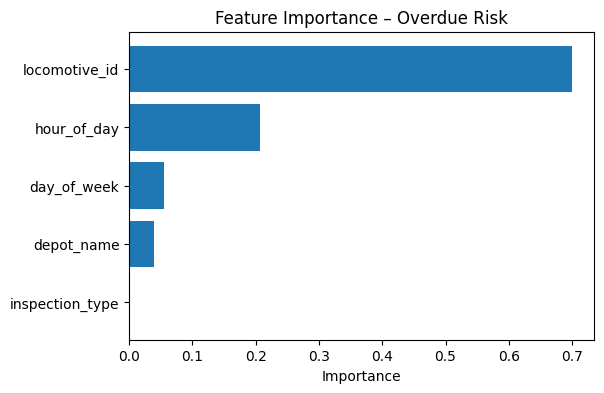

In [23]:
plt.figure(figsize=(6,4))
plt.barh(
    importances["feature"],
    importances["importance"]
)
plt.gca().invert_yaxis()
plt.title("Feature Importance – Overdue Risk")
plt.xlabel("Importance")
plt.show()


In [24]:
test_results.to_csv(
    "task2_overdue_risk_predictions.csv",
    index=False
)

importances.to_csv(
    "task2_feature_importance.csv",
    index=False
)

print("task 2 natijalari CSV fayllarga saqlandi")


task 2 natijalari CSV fayllarga saqlandi


In [25]:
from google.colab import files
files.download("task2_overdue_risk_predictions.csv")
files.download("task2_feature_importance.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>